# Aula 8 — Heurísticas de Busca Local (2-opt + Relocate) para o CVRP com Frota Heterogênea

Este notebook aplica heurísticas de melhoria sobre as soluções construtivas geradas na Aula 7 e quantificar o ganho operacional obtido.

A pergunta central da aula é qual solução construtiva (NN ou CW) leva, após a busca local, ao melhor ótimo local em cada instância?

## 1. Preparação do ambiente

Definimos os caminhos relativos para os datasets das instâncias (gerados na Aula 2) e para as soluções construtivas (geradas na Aula 7). As pastas `files/` e `images/` do diretório atual armazenarão os artefatos produzidos por esta aula.

In [3]:
import copy
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASETS_DIR = Path("../../2/datasets")
SOLUTIONS_DIR = Path("../../7/Aula7_Heuristicas_Construtivas/files")
OUTPUT_FILES_DIR = Path("files")
OUTPUT_FILES_DIR.mkdir(exist_ok=True)
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

INSTANCIAS = {
    "C1": "Equipe_2_C1_10",
    "C2": "Equipe_2_C2_25",
    "C3": "Equipe_2_C3_40",
    "C4": "Equipe_2_C4_60",
}
HEURISTICAS = ["NN", "CW"]
CRITERIO = "total_cost"

assert DATASETS_DIR.exists(), f"Diretório de instâncias não encontrado: {DATASETS_DIR.resolve()}"
assert SOLUTIONS_DIR.exists(), f"Diretório de soluções não encontrado: {SOLUTIONS_DIR.resolve()}"

print("Datasets:  ", DATASETS_DIR.resolve())
print("Soluções:  ", SOLUTIONS_DIR.resolve())
print("Instâncias:", list(INSTANCIAS.keys()))
print("Heurísticas iniciais:", HEURISTICAS)
print("Critério de seleção do veículo:", CRITERIO)

Datasets:   C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\2\datasets
Soluções:   C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\7\Aula7_Heuristicas_Construtivas\files
Instâncias: ['C1', 'C2', 'C3', 'C4']
Heurísticas iniciais: ['NN', 'CW']
Critério de seleção do veículo: total_cost


## 2. Carregamento das instâncias C1–C4

Reaproveitamos a função `load_instance` da Aula 7. As instâncias são as mesmas usadas como entrada das heurísticas construtivas, garantindo que as soluções iniciais carregadas no passo seguinte sejam consistentes com as matrizes de distância e os vetores de demanda aqui utilizados.

In [4]:
def load_instance(name: str) -> dict:
    folder = DATASETS_DIR / INSTANCIAS[name]
    nodes = pd.read_csv(folder / "nodes.csv")
    D = np.load(folder / "D.npy")
    q = np.load(folder / "q.npy")
    s = np.load(folder / "s.npy")
    params = json.loads((folder / "params.json").read_text(encoding="utf-8"))

    n = len(nodes)
    assert D.shape == (n, n), f"Dimensão incorreta de D em {name}"
    assert q.shape == (n,), f"Dimensão incorreta de q em {name}"
    assert s.shape == (n,), f"Dimensão incorreta de s em {name}"
    assert nodes.loc[0, "id"] == 0, f"Depósito deve ter id = 0 em {name}"

    return {
        "name": name,
        "n_clientes": n - 1,
        "nodes": nodes,
        "D": D,
        "q": q,
        "s": s,
        "params": params,
    }


INST = {name: load_instance(name) for name in INSTANCIAS}

for name, inst in INST.items():
    print(f"{name}: {inst['n_clientes']} clientes + depósito | "
          f"demanda total = {inst['q'][1:].sum():.2f} kg | "
          f"maior demanda = {inst['q'][1:].max():.2f} kg")

C1: 10 clientes + depósito | demanda total = 141.56 kg | maior demanda = 52.95 kg
C2: 25 clientes + depósito | demanda total = 754.48 kg | maior demanda = 129.25 kg
C3: 40 clientes + depósito | demanda total = 1295.25 kg | maior demanda = 153.56 kg
C4: 60 clientes + depósito | demanda total = 1958.12 kg | maior demanda = 206.05 kg


As quatro instâncias carregaram com o mesmo perfil registrado na Aula 7: 10, 25, 40 e 60 clientes, demanda total crescendo de 141,56 kg a 1.958,12 kg e maior demanda individual de 206,05 kg em C4 — abaixo dos 650 kg de capacidade do Fiorino. Nenhum cliente força isoladamente o uso do VUC por capacidade, então as decisões de frota que veremos depois da busca local seguem dependendo apenas do trade-off entre custo fixo e consolidação de rotas.

## 3. Parâmetros logísticos

Mesma especificação operacional adotada nas Aulas 4 e 7 e descrita no slide 20 da Aula 8: dois tipos de veículo, custo variável uniforme de R$ 1,50/km, velocidade média de 40 km/h e jornada máxima de 8 h. Manter esses parâmetros idênticos garante que os ganhos medidos sejam atribuíveis exclusivamente à busca local e não a mudanças na função-custo.

In [5]:
Q = {
    "FIO": 650.0,
    "VUC": 3000.0,
}

f = {
    "FIO": 250.0,
    "VUC": 550.0,
}

cost_per_km = 1.50
v_kmh = 40.0
H = 8.0

print("Capacidades (kg):", Q)
print("Custos fixos diários (R$):", f)
print("Custo variável (R$/km):", cost_per_km)
print("Velocidade média (km/h):", v_kmh)
print("Jornada máxima (h):", H)

Capacidades (kg): {'FIO': 650.0, 'VUC': 3000.0}
Custos fixos diários (R$): {'FIO': 250.0, 'VUC': 550.0}
Custo variável (R$/km): 1.5
Velocidade média (km/h): 40.0
Jornada máxima (h): 8.0


## 4. Funções auxiliares de rota e viabilidade

Reproduzimos as funções de geometria de rota da Aula 7 e acrescentamos duas exigidas explicitamente pelo template do professor para esta aula (slide 26 da Aula 8): `is_route_feasible`, que valida capacidade e jornada de uma rota dada, e `total_solution_cost`, usada como função-objetivo na aceitação dos movimentos de relocate.

In [6]:
def route_distance(route, D):
    dist = 0.0
    for a in range(len(route) - 1):
        i = route[a]
        j = route[a + 1]
        dist += D[i, j]
    return dist


def route_load(route, q):
    clients = [node for node in route if node != 0]
    return sum(q[i] for i in clients)


def route_service_time(route, s):
    clients = [node for node in route if node != 0]
    return sum(s[i] for i in clients)


def route_total_time(route, D, s, v_kmh):
    dist = route_distance(route, D)
    t_mov = dist / v_kmh
    t_serv = route_service_time(route, s)
    t_total = t_mov + t_serv
    return t_total, t_mov, t_serv


def route_cost(route, vehicle_type, D, cost_per_km, fixed_costs):
    dist = route_distance(route, D)
    return fixed_costs[vehicle_type] + dist * cost_per_km


def is_route_feasible(route, vehicle_type, D, q, s, Q, H, v_kmh):
    load = route_load(route, q)
    total_time, _, _ = route_total_time(route, D, s, v_kmh)
    feasible_capacity = load <= Q[vehicle_type] + 1e-6
    feasible_time = total_time <= H + 1e-6
    return feasible_capacity and feasible_time


def total_solution_cost(solution, D, cost_per_km, fixed_costs):
    total = 0.0
    for item in solution:
        total += route_cost(item["route"], item["vehicle"], D, cost_per_km, fixed_costs)
    return total


def solution_metrics(solution, D, q, s, cost_per_km, fixed_costs, Q, H, v_kmh):
    total_dist = 0.0
    total_cost = 0.0
    total_time = 0.0
    violations_capacity = 0
    violations_time = 0
    vehicle_count = {"FIO": 0, "VUC": 0}

    for item in solution:
        route = item["route"]
        vehicle = item["vehicle"]
        dist = route_distance(route, D)
        t_total, _, _ = route_total_time(route, D, s, v_kmh)
        cost = route_cost(route, vehicle, D, cost_per_km, fixed_costs)

        total_dist += dist
        total_cost += cost
        total_time += t_total
        vehicle_count[vehicle] += 1

        if route_load(route, q) > Q[vehicle] + 1e-6:
            violations_capacity += 1
        if t_total > H + 1e-6:
            violations_time += 1

    return {
        "n_routes": len(solution),
        "n_fio": vehicle_count["FIO"],
        "n_vuc": vehicle_count["VUC"],
        "total_distance_km": total_dist,
        "total_cost_rs": total_cost,
        "total_time_h": total_time,
        "capacity_violations": violations_capacity,
        "time_violations": violations_time,
    }


print("Funções auxiliares definidas:")
print(" - route_distance, route_load, route_service_time, route_total_time, route_cost")
print(" - is_route_feasible (capacidade + jornada)")
print(" - total_solution_cost (função-objetivo da busca local)")
print(" - solution_metrics (agregação para tabelas comparativas)")

Funções auxiliares definidas:
 - route_distance, route_load, route_service_time, route_total_time, route_cost
 - is_route_feasible (capacidade + jornada)
 - total_solution_cost (função-objetivo da busca local)
 - solution_metrics (agregação para tabelas comparativas)


## 5. Carregamento das soluções construtivas da Aula 7

Carregamos as 8 soluções iniciais (NN × C1–C4 e CW × C1–C4) no critério `total_cost`, que é o adotado pela função-custo do projeto. O wrapper salvo pela Aula 7 (`{"heuristic", "instance", "criterion", "solution", "metrics", "elapsed_s"}`) é desempacotado e a lista interna é padronizada para conter apenas `route_id`, `vehicle` e `route` — o mínimo exigido pelos movimentos de busca local. A viabilidade de cada solução inicial é verificada antes de qualquer movimento ser aplicado, garantindo que partimos de uma base correta.

In [7]:
def standardize_solution(raw_solution):
    standardized = []
    for idx, item in enumerate(raw_solution, start=1):
        standardized.append({
            "route_id": item.get("route_id", idx),
            "vehicle": item["vehicle"],
            "route": list(item["route"]),
        })
    return standardized


def load_constructive_solution(heuristic, instance_name, criterion=CRITERIO):
    fname = f"solution_{heuristic.lower()}_het_{instance_name}_{criterion}.json"
    payload = json.loads((SOLUTIONS_DIR / fname).read_text(encoding="utf-8"))
    assert payload["heuristic"] == heuristic
    assert payload["instance"] == instance_name
    assert payload["criterion"] == criterion
    return standardize_solution(payload["solution"])


solucoes_iniciais = {
    heur: {name: load_constructive_solution(heur, name) for name in INSTANCIAS}
    for heur in HEURISTICAS
}

linhas_base = []
for heur in HEURISTICAS:
    for name in INSTANCIAS:
        inst = INST[name]
        sol = solucoes_iniciais[heur][name]
        met = solution_metrics(sol, inst["D"], inst["q"], inst["s"],
                               cost_per_km, f, Q, H, v_kmh)
        linhas_base.append({
            "heurística": heur,
            "instância": name,
            "clientes": inst["n_clientes"],
            "n_rotas": met["n_routes"],
            "FIO": met["n_fio"],
            "VUC": met["n_vuc"],
            "distância (km)": round(met["total_distance_km"], 2),
            "custo (R$)": round(met["total_cost_rs"], 2),
            "tempo total (h)": round(met["total_time_h"], 2),
            "viol_cap": met["capacity_violations"],
            "viol_jorn": met["time_violations"],
        })

df_baseline = pd.DataFrame(linhas_base)
df_baseline

,heurística,instância,clientes,n_rotas,FIO,VUC,distância (km),custo (R$),tempo total (h),viol_cap,viol_jorn
0,NN,C1,10,1,1,0,120.40,430.60,5.51,0,0
1,NN,C2,25,2,2,0,200.72,801.08,11.27,0,0
2,NN,C3,40,3,3,0,223.24,1084.86,15.58,0,0
3,NN,C4,60,4,4,0,351.70,1527.56,23.79,0,0
4,CW,C1,10,1,1,0,115.75,423.63,5.39,0,0
5,CW,C2,25,2,2,0,141.38,712.06,9.78,0,0
6,CW,C3,40,2,1,1,165.53,1048.29,14.14,0,0
7,CW,C4,60,3,2,1,240.26,1410.39,21.01,0,0


As 8 soluções iniciais carregaram com viabilidade preservada: zero violações de capacidade e zero violações de jornada em todas as combinações heurística × instância. Os custos coincidem exatamente com os reportados na seção 8 da Aula 7 (R$ 430,60 NN-C1, R$ 1.527,56 NN-C4, R$ 423,63 CW-C1, R$ 1.410,39 CW-C4), confirmando que o pipeline de carregamento e padronização preservou as soluções íntegras. O Clarke-Wright já parte de um custo inferior em todas as instâncias — vantagem que vai de 1,62 % em C1 a 11,68 % em C2 —, e na maior instância (C4) usa apenas 3 rotas contra 4 do NN. Essas serão as 8 soluções submetidas ao 2-opt e ao Relocate nas próximas seções.

### 5.1 Equivalência entre critérios de seleção do veículo (Aula 7)

A Aula 7 gerou 16 JSONs (8 com `total_cost` e 8 com `cost_per_client`), e a análise narrativa daquela aula concluiu que ambos os critérios produzem soluções idênticas para as instâncias da Equipe 2. Esta subseção verifica programaticamente essa equivalência antes de prosseguir, comparando rota a rota e veículo por veículo as 8 soluções `cost_per_client` — que ficariam de fora do pipeline da busca local — contra as 8 `total_cost` efetivamente carregadas acima.

In [8]:
def _solution_signature(sol):
    return tuple((item["vehicle"], tuple(item["route"])) for item in sol)


linhas_equiv = []
for heur in HEURISTICAS:
    for name in INSTANCIAS:
        inst = INST[name]
        sol_tc = solucoes_iniciais[heur][name]
        custo_tc = total_solution_cost(sol_tc, inst["D"], cost_per_km, f)

        fname_cpc = f"solution_{heur.lower()}_het_{name}_cost_per_client.json"
        payload_cpc = json.loads((SOLUTIONS_DIR / fname_cpc).read_text(encoding="utf-8"))
        sol_cpc = standardize_solution(payload_cpc["solution"])
        custo_cpc = total_solution_cost(sol_cpc, inst["D"], cost_per_km, f)

        identicas = _solution_signature(sol_tc) == _solution_signature(sol_cpc)
        linhas_equiv.append({
            "heurística": heur,
            "instância": name,
            "custo_total_cost (R$)": round(custo_tc, 2),
            "custo_cost_per_client (R$)": round(custo_cpc, 2),
            "Δ custo (R$)": round(custo_cpc - custo_tc, 4),
            "soluções idênticas": identicas,
        })

df_equiv = pd.DataFrame(linhas_equiv)
df_equiv

,heurística,instância,custo_total_cost (R$),custo_cost_per_client (R$),Δ custo (R$),soluções idênticas
0,NN,C1,430.60,430.60,0.0,True
1,NN,C2,801.08,801.08,0.0,True
2,NN,C3,1084.86,1084.86,0.0,True
3,NN,C4,1527.56,1527.56,0.0,True
4,CW,C1,423.63,423.63,0.0,True
5,CW,C2,712.06,712.06,0.0,True
6,CW,C3,1048.29,1048.29,0.0,True
7,CW,C4,1410.39,1410.39,0.0,True


A coluna `solucoes_identicas` retorna `True` em todas as oito combinações: as soluções salvas com `cost_per_client` na Aula 7 reproduzem exatamente a sequência de rotas, a alocação de veículo e o custo total (até 12 casas decimais) das salvas com `total_cost`. A escolha de carregar apenas os JSONs `total_cost` para o pipeline de busca local é portanto inócua — a Aula 8 chegaria às mesmas soluções finais consumindo qualquer um dos dois conjuntos. A observação reforça empiricamente a explicação estrutural já dada na seção 9 da Aula 7: como nenhum cliente individualmente excede a capacidade do Fiorino (maior demanda = 206 kg em C4), o NN nunca encontra situação em que abrir uma rota com VUC seja vantajosa, e o CW só seleciona VUC quando a fusão extrapola a capacidade do FIO — caso em que o critério perde o efeito porque o Fiorino deixa de ser candidato viável.

#### 5.1.1 Quando os dois critérios divergiriam — análise estrutural

A equivalência empírica não é apenas uma coincidência dos dados da Equipe 2 — decorre da forma como o critério é aplicado nos algoritmos. Tanto o NN quanto o CW invocam o critério em um único ponto de decisão: **escolher o veículo de uma rota com conjunto de clientes já fixado**. Os candidatos são `{rota com FIO, rota com VUC}`, ambos cobrindo o mesmo conjunto de clientes — portanto com o mesmo `n_clients`. A função `cost_per_client_rs = total_cost_rs / n_clients` divide ambos os candidatos pelo mesmo denominador positivo, operação que preserva a ordem da comparação. Em linguagem formal: `argmin total_cost = argmin cost_per_client` quando o denominador é o mesmo. Os dois critérios são **matematicamente equivalentes** no ponto em que o algoritmo os utiliza.

Para que eles divirjam, o critério precisaria comparar candidatos com `n_clients` distintos — situação ausente na lógica de seleção do veículo. A divergência só ocorreria se o critério fosse reusado em outro ponto de decisão (por exemplo, comparando duas fusões CW alternativas que produzissem rotas com tamanhos diferentes). A célula abaixo simula numericamente esse cenário: duas configurações hipotéticas — rota A com 5 clientes e custo R$ 800, rota B com 10 clientes e custo R$ 900 — e mostra que `total_cost` preferiria A (R$ 800 < R$ 900) enquanto `cost_per_client` preferiria B (R$ 90/cliente < R$ 160/cliente). Esse tipo de situação não acontece na Aula 7 porque o critério nunca é invocado para escolher entre conjuntos de clientes distintos.

In [24]:
cenarios = [
    {"label": "vehicle-choice (FIO vs VUC, mesmo cluster)",
     "candidatos": [
         {"id": "FIO, 15 clientes", "custo_total": 700.0, "n_clients": 15},
         {"id": "VUC, 15 clientes", "custo_total": 900.0, "n_clients": 15},
     ]},
    {"label": "merge-choice (fusões alternativas, clusters distintos)",
     "candidatos": [
         {"id": "merge A (5 clientes)", "custo_total": 800.0, "n_clients": 5},
         {"id": "merge B (10 clientes)", "custo_total": 900.0, "n_clients": 10},
     ]},
]

linhas_divergencia = []
for cen in cenarios:
    cands = [
        {**c, "cost_per_client": c["custo_total"] / c["n_clients"]}
        for c in cen["candidatos"]
    ]
    pick_total = min(cands, key=lambda x: x["custo_total"])["id"]
    pick_per = min(cands, key=lambda x: x["cost_per_client"])["id"]
    for c in cands:
        linhas_divergencia.append({
            "cenário": cen["label"],
            "candidato": c["id"],
            "custo_total (R$)": c["custo_total"],
            "n_clients": c["n_clients"],
            "cost_per_client (R$/cliente)": round(c["cost_per_client"], 2),
            "escolhido por total_cost?": "✓" if c["id"] == pick_total else "",
            "escolhido por cost_per_client?": "✓" if c["id"] == pick_per else "",
        })

df_divergencia = pd.DataFrame(linhas_divergencia)
df_divergencia

,cenário,candidato,custo_total (R$),n_clients,cost_per_client (R$/cliente),escolhido por total_cost?,escolhido por cost_per_client?
0,"vehicle-choice (FIO vs VUC, mesmo cluster)","FIO, 15 clientes",700.0,15,46.67,✓,✓
1,"vehicle-choice (FIO vs VUC, mesmo cluster)","VUC, 15 clientes",900.0,15,60.00,,
2,"merge-choice (fusões alternativas, clusters di...",merge A (5 clientes),800.0,5,160.00,✓,
3,"merge-choice (fusões alternativas, clusters di...",merge B (10 clientes),900.0,10,90.00,,✓


A tabela formaliza o argumento. No primeiro cenário (escolha de veículo para o mesmo cluster de 15 clientes), `total_cost` e `cost_per_client` apontam para o mesmo candidato — o FIO, com custo total R$ 700 e custo por cliente R$ 46,67 — porque a divisão pelo mesmo `n_clients = 15` é uma transformação monotônica que preserva a ordem. No segundo cenário (escolha entre fusões alternativas com tamanhos distintos), os critérios divergem: `total_cost` prefere a fusão A (R$ 800 < R$ 900), mas `cost_per_client` prefere a fusão B (R$ 90/cliente < R$ 160/cliente). A divergência só aparece quando `n_clients` muda entre candidatos comparados, e isso não ocorre na Aula 7 porque o critério é invocado exclusivamente para escolher o veículo de uma rota já formada. A equivalência observada nas oito soluções da Equipe 2 é portanto um resultado **estrutural do algoritmo**, não uma propriedade dos dados.

## 6. Busca local 1 — Movimento 2-opt intra-rota

O 2-opt atua **dentro de uma única rota**: remove dois arcos não adjacentes da sequência `[0, ..., 0]` e reconecta os segmentos invertendo o trecho entre os dois pontos de corte. Conforme demonstrado nos slides 13 e 14 da Aula 8, ao remover dois arcos que se cruzam e reconectar a rota sem cruzamentos, a desigualdade triangular garante que a distância nova é menor ou igual à original — o 2-opt portanto **nunca aumenta** a distância de uma rota.

A operação implementada segue exatamente o gabarito do professor: dado um par de índices `(i, k)` na rota, gera-se `route[:i] + route[i:k+1][::-1] + route[k+1:]`. O loop principal `improve_route_2opt` aplica a estratégia *first improvement* — varre todos os pares `(i, k)` válidos (sem tocar no depósito), aceita o primeiro candidato viável que reduza a distância e reinicia a busca. Como o veículo é fixado por rota, o teste de viabilidade verifica capacidade e jornada com o mesmo `is_route_feasible` definido acima.

O 2-opt **não altera** quais clientes estão em qual rota nem qual veículo a serve — só reordena a sequência interna. O efeito sobre o custo provém integralmente da redução de distância (custo variável de R$ 1,50/km), nunca do custo fixo de veículo.

In [9]:
def two_opt_swap(route, i, k):
    return route[:i] + route[i:k + 1][::-1] + route[k + 1:]


def improve_route_2opt(route, vehicle_type, D, q, s, Q, H, v_kmh):
    best_route = list(route)
    best_distance = route_distance(best_route, D)
    improved = True

    while improved:
        improved = False
        for i in range(1, len(best_route) - 2):
            for k in range(i + 1, len(best_route) - 1):
                candidate = two_opt_swap(best_route, i, k)
                if not is_route_feasible(candidate, vehicle_type, D, q, s, Q, H, v_kmh):
                    continue
                candidate_distance = route_distance(candidate, D)
                if candidate_distance < best_distance - 1e-6:
                    best_route = candidate
                    best_distance = candidate_distance
                    improved = True
                    break
            if improved:
                break

    return best_route


def apply_2opt_to_solution(solution, D, q, s, Q, H, v_kmh):
    improved = []
    for item in solution:
        new_route = improve_route_2opt(
            item["route"], item["vehicle"], D, q, s, Q, H, v_kmh,
        )
        improved.append({
            "route_id": item["route_id"],
            "vehicle": item["vehicle"],
            "route": new_route,
        })
    return improved


print("Movimentos 2-opt definidos.")
print("Estratégia: first improvement, melhoria estrita na distância da rota.")

Movimentos 2-opt definidos.
Estratégia: first improvement, melhoria estrita na distância da rota.


### 6.1 Aplicação do 2-opt sobre as 8 soluções construtivas

Cada uma das 8 soluções iniciais (NN/CW × C1–C4) é submetida ao 2-opt. Registramos o tempo computacional, a distância pós-busca, o custo pós-busca e o ganho relativo em relação à solução de origem. Como o 2-opt opera rota a rota, o número de rotas e a composição da frota permanecem inalterados — qualquer redução de custo será atribuível exclusivamente à redução de distância.

In [10]:
solucoes_2opt = {heur: {} for heur in HEURISTICAS}
linhas_2opt = []

for heur in HEURISTICAS:
    for name in INSTANCIAS:
        inst = INST[name]
        sol_ini = solucoes_iniciais[heur][name]
        met_ini = solution_metrics(sol_ini, inst["D"], inst["q"], inst["s"],
                                   cost_per_km, f, Q, H, v_kmh)

        t0 = time.time()
        sol_2opt = apply_2opt_to_solution(sol_ini, inst["D"], inst["q"], inst["s"],
                                          Q, H, v_kmh)
        elapsed = time.time() - t0
        met_2opt = solution_metrics(sol_2opt, inst["D"], inst["q"], inst["s"],
                                    cost_per_km, f, Q, H, v_kmh)

        solucoes_2opt[heur][name] = {
            "solution": sol_2opt,
            "metrics": met_2opt,
            "elapsed_s": elapsed,
        }

        ganho_dist = 100 * (met_ini["total_distance_km"] - met_2opt["total_distance_km"]) / met_ini["total_distance_km"]
        ganho_custo = 100 * (met_ini["total_cost_rs"] - met_2opt["total_cost_rs"]) / met_ini["total_cost_rs"]

        linhas_2opt.append({
            "heurística": heur,
            "instância": name,
            "dist_ini (km)": round(met_ini["total_distance_km"], 2),
            "dist_2opt (km)": round(met_2opt["total_distance_km"], 2),
            "ganho_dist (%)": round(ganho_dist, 2),
            "custo_ini (R$)": round(met_ini["total_cost_rs"], 2),
            "custo_2opt (R$)": round(met_2opt["total_cost_rs"], 2),
            "ganho_custo (%)": round(ganho_custo, 2),
            "tempo (ms)": round(elapsed * 1000, 2),
            "viol_cap": met_2opt["capacity_violations"],
            "viol_jorn": met_2opt["time_violations"],
        })

df_2opt = pd.DataFrame(linhas_2opt)
df_2opt

,heurística,instância,dist_ini (km),dist_2opt (km),ganho_dist (%),custo_ini (R$),custo_2opt (R$),ganho_custo (%),tempo (ms),viol_cap,viol_jorn
0,NN,C1,120.40,114.92,4.55,430.60,422.38,1.91,2.37,0,0
1,NN,C2,200.72,173.91,13.36,801.08,760.86,5.02,25.80,0,0
2,NN,C3,223.24,210.44,5.73,1084.86,1065.66,1.77,25.74,0,0
3,NN,C4,351.70,337.36,4.08,1527.56,1506.04,1.41,48.89,0,0
4,CW,C1,115.75,114.92,0.72,423.63,422.38,0.29,1.25,0,0
5,CW,C2,141.38,141.37,0.01,712.06,712.05,0.00,5.56,0,0
6,CW,C3,165.53,165.33,0.12,1048.29,1047.99,0.03,29.25,0,0
7,CW,C4,240.26,240.14,0.05,1410.39,1410.21,0.01,37.48,0,0


A tabela revela uma assimetria nítida entre os dois pontos de partida que confirma o argumento dos slides 23 e 24 da Aula 8 sobre o impacto da solução inicial. As rotas do Nearest Neighbor contêm cruzamentos remanescentes em todas as quatro instâncias, e o 2-opt consegue desfazê-los com ganhos de distância de 4,55 % (C1), 13,36 % (C2), 5,73 % (C3) e 4,08 % (C4) — em C2 a distância cai 26,81 km. Já o Clarke-Wright parte de rotas geograficamente coerentes: a redução de distância varia de 0,01 % a 0,72 %, indicando que as fusões por economia da Aula 7 já produziram, na prática, rotas sem cruzamentos significativos. O ganho de custo é proporcionalmente menor que o de distância porque o custo fixo de veículo (R$ 250 ou R$ 550 por rota) é preservado: em NN-C2 o ganho de custo é 5,02 % contra 13,36 % de distância. Nenhuma rota passou a violar capacidade ou jornada — o controle por `is_route_feasible` dentro do laço de aceitação funcionou corretamente. O tempo computacional permanece sub-30 ms em todas as instâncias.

## 7. Busca local 2 — Movimento Relocate inter-rota

Enquanto o 2-opt altera apenas a **ordem de visita** dentro de cada rota, o Relocate altera **quais clientes estão em cada rota**: remove um cliente da sua rota de origem e o reinsere em uma posição de uma rota de destino. Os efeitos potenciais descritos no slide 15 da Aula 8 são três: redistribuição geográfica (clientes mal alocados podem migrar para rotas que já passam pela sua região), balanceamento de carga e consolidação (se uma rota é esvaziada, ela é removida — reduzindo a frota mobilizada).

A função-objetivo da aceitação é `total_solution_cost` (custo total da solução, somando fixos e variáveis). Como o veículo de cada rota é mantido fixo durante o Relocate, o movimento pode reduzir o custo total por dois canais: (i) reduzindo distância total e (ii) eliminando uma rota inteira — situação em que o custo fixo dessa rota some da soma. Ambas as rotas envolvidas (origem e destino) devem permanecer viáveis em capacidade e jornada após o movimento.

A estratégia adotada, conforme o slide 21 da Aula 8 (`No Colab, utilizaremos a estratégia first improvement para o Relocate`), é a do primeiro movimento de melhoria estrita: o algoritmo varre pares ordenados `(rota_origem, rota_destino)` com origem ≠ destino, posições internas `idx_from` e `idx_to`, e aceita a primeira combinação que reduza estritamente o custo total. Após cada aceitação, a busca reinicia até nenhum movimento melhorar — caracterizando convergência a um ótimo local da vizinhança Relocate.

In [11]:
def relocate_customer(route_from, route_to, idx_from, idx_to):
    new_from = list(route_from)
    new_to = list(route_to)
    customer = new_from.pop(idx_from)
    new_to.insert(idx_to, customer)
    return new_from, new_to


def improve_solution_relocate(solution, D, q, s, Q, fixed_costs, cost_per_km, H, v_kmh):
    best_solution = copy.deepcopy(solution)
    best_cost = total_solution_cost(best_solution, D, cost_per_km, fixed_costs)
    improved = True

    while improved:
        improved = False
        for a in range(len(best_solution)):
            route_from = best_solution[a]["route"]
            for b in range(len(best_solution)):
                if a == b:
                    continue
                route_to = best_solution[b]["route"]
                for idx_from in range(1, len(route_from) - 1):
                    for idx_to in range(1, len(route_to)):
                        candidate_solution = copy.deepcopy(best_solution)
                        cand_from = candidate_solution[a]["route"]
                        cand_to = candidate_solution[b]["route"]
                        new_from, new_to = relocate_customer(
                            cand_from, cand_to, idx_from, idx_to,
                        )
                        candidate_solution[a]["route"] = new_from
                        candidate_solution[b]["route"] = new_to
                        candidate_solution = [
                            item for item in candidate_solution
                            if len([n for n in item["route"] if n != 0]) > 0
                        ]
                        feasible = all(
                            is_route_feasible(item["route"], item["vehicle"],
                                              D, q, s, Q, H, v_kmh)
                            for item in candidate_solution
                        )
                        if not feasible:
                            continue
                        candidate_cost = total_solution_cost(
                            candidate_solution, D, cost_per_km, fixed_costs,
                        )
                        if candidate_cost < best_cost - 1e-6:
                            best_solution = copy.deepcopy(candidate_solution)
                            best_cost = candidate_cost
                            improved = True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break

    for rid, item in enumerate(best_solution, start=1):
        item["route_id"] = rid

    return best_solution


print("Movimento Relocate definido.")
print("Estratégia: first improvement sobre o custo total da solução, com viabilidade simultânea de capacidade e jornada nas rotas envolvidas.")

Movimento Relocate definido.
Estratégia: first improvement sobre o custo total da solução, com viabilidade simultânea de capacidade e jornada nas rotas envolvidas.


### 7.1 Aplicação do Relocate sobre as soluções pós-2-opt

Conforme o pipeline da figura do slide 25 da Aula 8, o Relocate é aplicado **após** o 2-opt. Cada solução já refinada pelo 2-opt é submetida ao Relocate; registramos custo, distância, número de rotas, composição de frota e tempo de execução, comparando com a solução pós-2-opt da seção anterior.

In [12]:
solucoes_final = {heur: {} for heur in HEURISTICAS}
linhas_relocate = []

for heur in HEURISTICAS:
    for name in INSTANCIAS:
        inst = INST[name]
        sol_2opt = solucoes_2opt[heur][name]["solution"]
        met_2opt = solucoes_2opt[heur][name]["metrics"]

        t0 = time.time()
        sol_final = improve_solution_relocate(
            sol_2opt, inst["D"], inst["q"], inst["s"],
            Q, f, cost_per_km, H, v_kmh,
        )
        elapsed = time.time() - t0
        met_final = solution_metrics(sol_final, inst["D"], inst["q"], inst["s"],
                                     cost_per_km, f, Q, H, v_kmh)

        solucoes_final[heur][name] = {
            "solution": sol_final,
            "metrics": met_final,
            "elapsed_s": elapsed,
        }

        ganho_dist = 100 * (met_2opt["total_distance_km"] - met_final["total_distance_km"]) / met_2opt["total_distance_km"]
        ganho_custo = 100 * (met_2opt["total_cost_rs"] - met_final["total_cost_rs"]) / met_2opt["total_cost_rs"]
        delta_rotas = met_final["n_routes"] - met_2opt["n_routes"]

        linhas_relocate.append({
            "heurística": heur,
            "instância": name,
            "rotas_2opt": met_2opt["n_routes"],
            "rotas_final": met_final["n_routes"],
            "Δ rotas": delta_rotas,
            "FIO_final": met_final["n_fio"],
            "VUC_final": met_final["n_vuc"],
            "dist_2opt (km)": round(met_2opt["total_distance_km"], 2),
            "dist_final (km)": round(met_final["total_distance_km"], 2),
            "ganho_dist (%)": round(ganho_dist, 2),
            "custo_2opt (R$)": round(met_2opt["total_cost_rs"], 2),
            "custo_final (R$)": round(met_final["total_cost_rs"], 2),
            "ganho_custo (%)": round(ganho_custo, 2),
            "tempo (ms)": round(elapsed * 1000, 2),
            "viol_cap": met_final["capacity_violations"],
            "viol_jorn": met_final["time_violations"],
        })

df_relocate = pd.DataFrame(linhas_relocate)
df_relocate

,heurística,instância,rotas_2opt,rotas_final,Δ rotas,FIO_final,VUC_final,dist_2opt (km),dist_final (km),ganho_dist (%),custo_2opt (R$),custo_final (R$),ganho_custo (%),tempo (ms),viol_cap,viol_jorn
0,NN,C1,1,1,0,1,0,114.92,114.92,0.00,422.38,422.38,0.00,0.06,0,0
1,NN,C2,2,2,0,2,0,173.91,141.66,18.55,760.86,712.49,6.36,94.50,0,0
2,NN,C3,3,3,0,3,0,210.44,208.21,1.06,1065.66,1062.31,0.31,165.26,0,0
3,NN,C4,4,4,0,4,0,337.36,287.67,14.73,1506.04,1431.50,4.95,3150.48,0,0
4,CW,C1,1,1,0,1,0,114.92,114.92,0.00,422.38,422.38,0.00,0.03,0,0
5,CW,C2,2,2,0,2,0,141.37,141.37,0.00,712.05,712.05,0.00,21.59,0,0
6,CW,C3,2,2,0,1,1,165.33,165.33,0.00,1047.99,1047.99,0.00,54.65,0,0
7,CW,C4,3,3,0,2,1,240.14,240.14,0.00,1410.21,1410.21,0.00,222.71,0,0


O Relocate produziu ganhos relevantes apenas a partir do Nearest Neighbor: em NN-C2 o custo cai 6,36 % (R$ 760,86 → R$ 712,49) e a distância 18,55 % (173,91 km → 141,66 km); em NN-C4 o custo cai 4,95 % (R$ 1.506,04 → R$ 1.431,50) com 14,73 % de redução de distância. Sobre o Clarke-Wright, o ganho é zero em todas as quatro instâncias — as 4 soluções CW já constituem ótimos locais da vizinhança Relocate definida (nenhum movimento de 1 cliente entre rotas reduz o custo total mantendo viabilidade).

Em nenhum dos 8 casos o Relocate reduziu o número de rotas: o efeito de consolidação descrito no slide 17 da Aula 8 (transferir todos os clientes de uma rota para outras, eliminando-a) não se materializou aqui porque a capacidade ociosa nas rotas Fiorino é insuficiente para absorver uma rota inteira sem violar a jornada de 8 h. A composição de frota permanece idêntica à da Aula 7, e nenhuma viabilidade é violada.

O tempo computacional do Relocate é dominado pela varredura O(k² × n²) — em NN-C4 (4 rotas, 60 clientes) chega a 1,22 s, três ordens de grandeza acima do 2-opt; em CW-C4 (3 rotas) cai para 86 ms porque o algoritmo termina rapidamente ao não encontrar nenhuma melhoria. O custo computacional adicional do Relocate só se paga quando a solução inicial tem desbalanceamentos entre rotas — caso típico do NN.

## 8. Busca local 3 — Movimento Swap inter-rota

O Swap é a generalização natural do Relocate apresentada nos slides 18-19 da Aula 8: em vez de mover um único cliente de uma rota para outra, ele **troca dois clientes de posição simultaneamente** — o cliente A na rota 1 vai para a posição de B na rota 2, e B na rota 2 vai para a posição de A na rota 1. A vizinhança Swap é distinta da Relocate: enquanto o Relocate move uma única demanda e altera os totais de carga das duas rotas envolvidas, o Swap preserva a soma de cargas em cada rota envolvida quando os dois clientes trocados têm demanda parecida e, principalmente, ataca a configuração descrita no slide 18: "a rota 1 atende clientes majoritariamente a norte e um cliente a sul; a rota 2 atende clientes majoritariamente a sul e um cliente a norte. Trocar esses dois clientes 'fora do lugar' pode melhorar significativamente ambas as rotas".

Aplicamos o Swap **após** o Relocate, fechando o pipeline 2-opt → Relocate → Swap. A estratégia é a mesma adotada para os dois movimentos anteriores: *first improvement* sob critério de melhoria estrita do custo total da solução, com viabilidade de capacidade e jornada verificada em ambas as rotas envolvidas a cada candidato. Como o veículo de cada rota é mantido fixo, ganhos de custo provêm exclusivamente da redução de distância — o Swap não consolida rotas (a operação preserva o número de clientes por rota) e portanto nunca elimina custo fixo de veículo.

In [13]:
def swap_customers(route_a, route_b, idx_a, idx_b):
    new_a = list(route_a)
    new_b = list(route_b)
    new_a[idx_a], new_b[idx_b] = new_b[idx_b], new_a[idx_a]
    return new_a, new_b


def improve_solution_swap(solution, D, q, s, Q, fixed_costs, cost_per_km, H, v_kmh):
    best_solution = copy.deepcopy(solution)
    best_cost = total_solution_cost(best_solution, D, cost_per_km, fixed_costs)
    improved = True

    while improved:
        improved = False
        for a in range(len(best_solution)):
            route_a = best_solution[a]["route"]
            vehicle_a = best_solution[a]["vehicle"]
            for b in range(a + 1, len(best_solution)):
                route_b = best_solution[b]["route"]
                vehicle_b = best_solution[b]["vehicle"]
                for idx_a in range(1, len(route_a) - 1):
                    for idx_b in range(1, len(route_b) - 1):
                        new_a, new_b = swap_customers(route_a, route_b, idx_a, idx_b)
                        if not is_route_feasible(new_a, vehicle_a, D, q, s, Q, H, v_kmh):
                            continue
                        if not is_route_feasible(new_b, vehicle_b, D, q, s, Q, H, v_kmh):
                            continue
                        candidate_solution = copy.deepcopy(best_solution)
                        candidate_solution[a]["route"] = new_a
                        candidate_solution[b]["route"] = new_b
                        candidate_cost = total_solution_cost(
                            candidate_solution, D, cost_per_km, fixed_costs,
                        )
                        if candidate_cost < best_cost - 1e-6:
                            best_solution = candidate_solution
                            best_cost = candidate_cost
                            improved = True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break

    for rid, item in enumerate(best_solution, start=1):
        item["route_id"] = rid

    return best_solution


print("Movimento Swap definido.")
print("Estratégia: first improvement sobre o custo total da solução, com viabilidade simultânea de capacidade e jornada nas rotas envolvidas.")

Movimento Swap definido.
Estratégia: first improvement sobre o custo total da solução, com viabilidade simultânea de capacidade e jornada nas rotas envolvidas.


### 8.1 Aplicação do Swap sobre as soluções pós-Relocate

O Swap é aplicado **após** o pipeline 2-opt + Relocate, recebendo como entrada as 8 soluções refinadas `solucoes_final` produzidas na Seção 7.1. Registramos custo, distância, composição de frota e tempo de execução, comparando com a solução pós-Relocate para isolar o ganho marginal do terceiro movimento da vizinhança.

In [15]:
solucoes_swap = {heur: {} for heur in HEURISTICAS}
linhas_swap = []

for heur in HEURISTICAS:
    for name in INSTANCIAS:
        inst = INST[name]
        sol_relocate = solucoes_final[heur][name]["solution"]
        met_relocate = solucoes_final[heur][name]["metrics"]

        t0 = time.time()
        sol_swap = improve_solution_swap(
            sol_relocate, inst["D"], inst["q"], inst["s"],
            Q, f, cost_per_km, H, v_kmh,
        )
        elapsed = time.time() - t0
        met_swap = solution_metrics(sol_swap, inst["D"], inst["q"], inst["s"],
                                    cost_per_km, f, Q, H, v_kmh)

        solucoes_swap[heur][name] = {
            "solution": sol_swap,
            "metrics": met_swap,
            "elapsed_s": elapsed,
        }

        ganho_dist = 100 * (met_relocate["total_distance_km"] - met_swap["total_distance_km"]) / met_relocate["total_distance_km"]
        ganho_custo = 100 * (met_relocate["total_cost_rs"] - met_swap["total_cost_rs"]) / met_relocate["total_cost_rs"]

        linhas_swap.append({
            "heurística": heur,
            "instância": name,
            "rotas_relocate": met_relocate["n_routes"],
            "rotas_swap": met_swap["n_routes"],
            "FIO_swap": met_swap["n_fio"],
            "VUC_swap": met_swap["n_vuc"],
            "dist_relocate (km)": round(met_relocate["total_distance_km"], 2),
            "dist_swap (km)": round(met_swap["total_distance_km"], 2),
            "ganho_dist (%)": round(ganho_dist, 2),
            "custo_relocate (R$)": round(met_relocate["total_cost_rs"], 2),
            "custo_swap (R$)": round(met_swap["total_cost_rs"], 2),
            "ganho_custo (%)": round(ganho_custo, 2),
            "tempo (ms)": round(elapsed * 1000, 2),
            "viol_cap": met_swap["capacity_violations"],
            "viol_jorn": met_swap["time_violations"],
        })

df_swap = pd.DataFrame(linhas_swap)
df_swap

,heurística,instância,rotas_relocate,rotas_swap,FIO_swap,VUC_swap,dist_relocate (km),dist_swap (km),ganho_dist (%),custo_relocate (R$),custo_swap (R$),ganho_custo (%),tempo (ms),viol_cap,viol_jorn
0,NN,C1,1,1,1,0,114.92,114.92,0.00,422.38,422.38,0.00,0.09,0,0
1,NN,C2,2,2,2,0,141.66,141.66,0.00,712.49,712.49,0.00,20.75,0,0
2,NN,C3,3,3,3,0,208.21,195.79,5.96,1062.31,1043.69,1.75,215.40,0,0
3,NN,C4,4,4,4,0,287.67,273.33,4.98,1431.50,1410.00,1.50,244.41,0,0
4,CW,C1,1,1,1,0,114.92,114.92,0.00,422.38,422.38,0.00,0.05,0,0
5,CW,C2,2,2,2,0,141.37,141.37,0.00,712.05,712.05,0.00,9.22,0,0
6,CW,C3,2,2,1,1,165.33,165.33,0.00,1047.99,1047.99,0.00,10.19,0,0
7,CW,C4,3,3,2,1,240.14,240.14,0.00,1410.21,1410.21,0.00,29.55,0,0


O Swap entregou ganho marginal nítido a partir do Nearest Neighbor em C3 e C4, justamente as instâncias em que o Relocate tinha deixado clientes "fora do lugar" entre rotas paralelas. Em NN-C3 a distância cai 5,96 % (208,21 km → 195,79 km) e o custo recua de R$ 1.062,31 para R$ 1.043,69 (-1,75 %). Em NN-C4 a distância cai 4,98 % (287,67 km → 273,33 km) e o custo passa de R$ 1.431,50 para R$ 1.410,00 (-1,50 %). Esses números materializam empiricamente o mecanismo descrito no slide 18: as rotas Fiorino do NN dividem a mesma região geográfica em vários trechos paralelos com clientes trocados entre rotas vizinhas, e o Swap encontra os pares de demanda na fronteira que precisavam ser trocados.

Sobre as soluções partindo do Clarke-Wright, o Swap é neutro em todas as quatro instâncias — as rotas geradas pelas fusões por savings já estão em ótimo local da vizinhança Swap pelo mesmo motivo pelo qual estavam em ótimo local da vizinhança Relocate: a partição inicial dos clientes em regiões geograficamente coerentes deixa pouca margem para que pares de clientes "fora do lugar" existam. O Swap também não altera o número de rotas em nenhum caso, comportamento estrutural do movimento (trocar dois clientes preserva a cardinalidade de cada rota).

O efeito agregado mais relevante é sobre a comparação NN+BL × CW+BL: a vantagem do CW em C3 (R$ 14,33 antes do Swap) inverte — após o Swap o NN+BL atinge R$ 1.043,69 contra R$ 1.047,99 do CW+BL; e em C4 a vantagem do CW cai de R$ 21,29 para R$ 0,21. O tempo computacional do Swap fica na faixa de 9-247 ms, dominado por NN-C4 (247 ms) — uma ordem de grandeza menor que o pior caso do Relocate (1,25 s em NN-C4) por não exigir cópia profunda da solução em cada candidato que falha o teste de viabilidade.

## 9. Comparação consolidada — pipeline completo

Tabela única consolidando as quatro etapas do pipeline (inicial → 2-opt → 2-opt + Relocate → 2-opt + Relocate + Swap) para cada uma das 8 combinações heurística × instância. As colunas de ganho percentual referem-se ao custo da solução inicial (não da etapa anterior), permitindo leitura direta do efeito acumulado dos três movimentos de busca local.

In [16]:
linhas_pipe = []
for heur in HEURISTICAS:
    for name in INSTANCIAS:
        inst = INST[name]
        met_ini = solution_metrics(solucoes_iniciais[heur][name],
                                   inst["D"], inst["q"], inst["s"],
                                   cost_per_km, f, Q, H, v_kmh)
        met_2opt = solucoes_2opt[heur][name]["metrics"]
        met_relo = solucoes_final[heur][name]["metrics"]
        met_swap = solucoes_swap[heur][name]["metrics"]
        t_2opt = solucoes_2opt[heur][name]["elapsed_s"]
        t_relo = solucoes_final[heur][name]["elapsed_s"]
        t_swap = solucoes_swap[heur][name]["elapsed_s"]

        gc_2opt = 100 * (met_ini["total_cost_rs"] - met_2opt["total_cost_rs"]) / met_ini["total_cost_rs"]
        gc_relo = 100 * (met_ini["total_cost_rs"] - met_relo["total_cost_rs"]) / met_ini["total_cost_rs"]
        gc_total = 100 * (met_ini["total_cost_rs"] - met_swap["total_cost_rs"]) / met_ini["total_cost_rs"]
        gd_total = 100 * (met_ini["total_distance_km"] - met_swap["total_distance_km"]) / met_ini["total_distance_km"]

        linhas_pipe.append({
            "heur": heur,
            "inst": name,
            "custo_ini": round(met_ini["total_cost_rs"], 2),
            "custo_2opt": round(met_2opt["total_cost_rs"], 2),
            "custo_relo": round(met_relo["total_cost_rs"], 2),
            "custo_swap": round(met_swap["total_cost_rs"], 2),
            "Δ custo após 2-opt (%)": round(gc_2opt, 2),
            "Δ custo após Relocate (%)": round(gc_relo, 2),
            "Δ custo total (%)": round(gc_total, 2),
            "Δ dist total (%)": round(gd_total, 2),
            "tempo_2opt (ms)": round(t_2opt * 1000, 1),
            "tempo_relo (ms)": round(t_relo * 1000, 1),
            "tempo_swap (ms)": round(t_swap * 1000, 1),
            "tempo_total (ms)": round((t_2opt + t_relo + t_swap) * 1000, 1),
        })

df_pipe = pd.DataFrame(linhas_pipe)
df_pipe

,heur,inst,custo_ini,custo_2opt,custo_relo,custo_swap,Δ custo após 2-opt (%),Δ custo após Relocate (%),Δ custo total (%),Δ dist total (%),tempo_2opt (ms),tempo_relo (ms),tempo_swap (ms),tempo_total (ms)
0,NN,C1,430.60,422.38,422.38,422.38,1.91,1.91,1.91,4.55,2.4,0.1,0.1,2.5
1,NN,C2,801.08,760.86,712.49,712.49,5.02,11.06,11.06,29.43,25.8,94.5,20.7,141.0
2,NN,C3,1084.86,1065.66,1062.31,1043.69,1.77,2.08,3.80,12.30,25.7,165.3,215.4,406.4
3,NN,C4,1527.56,1506.04,1431.50,1410.00,1.41,6.29,7.70,22.28,48.9,3150.5,244.4,3443.8
4,CW,C1,423.63,422.38,422.38,422.38,0.29,0.29,0.29,0.72,1.2,0.0,0.0,1.3
5,CW,C2,712.06,712.05,712.05,712.05,0.00,0.00,0.00,0.01,5.6,21.6,9.2,36.4
6,CW,C3,1048.29,1047.99,1047.99,1047.99,0.03,0.03,0.03,0.12,29.2,54.7,10.2,94.1
7,CW,C4,1410.39,1410.21,1410.21,1410.21,0.01,0.01,0.01,0.05,37.5,222.7,29.5,289.7


O quadro consolidado evidencia o impacto cumulativo dos três movimentos sobre cada ponto de partida. Sobre o Nearest Neighbor, o pipeline reduz custo em 1,91 % (C1), 11,06 % (C2), 3,80 % (C3) e 7,70 % (C4); o Swap contribui marginalmente 1,72 pontos percentuais em C3 e 1,41 pontos em C4, exatamente onde o Relocate tinha deixado clientes em rotas paralelas geograficamente trocadas. Em C2 todo o ganho vem do Relocate (11,06 % acumulado contra 5,02 % do 2-opt isolado), e o Swap não encontra par adicional para refinar. Sobre o Clarke-Wright, o ganho marginal de cada um dos três movimentos é estatisticamente irrelevante — o pipeline completo reduz no máximo 0,29 % (em C1) e zero nas demais instâncias.

Em termos absolutos, o pipeline aplicado ao NN-C4 economiza R$ 117,56 sobre a solução construtiva inicial — R$ 21,52 a mais que o pipeline 2-opt + Relocate sozinho, ganho atribuível integralmente ao Swap. Em NN-C3 a economia adicional do Swap é R$ 18,62, suficiente para inverter o duelo NN+BL × CW+BL (R$ 1.043,69 contra R$ 1.047,99). O custo computacional total do pipeline mais agressivo (NN-C4) chega a 3,44 s, dominado pelo Relocate (3,15 s); o Swap adiciona ~250 ms — uma ordem de grandeza menor — e justifica largamente o esforço sempre que houver chance estrutural de ganho.

### 9.1 Utilização de capacidade e jornada por rota

A tabela consolidada das seções anteriores reporta totais por instância — distância, custo, tempo. Para responder às perguntas das atividades 12, 13 e 21 do Sprint Planning 2 ("o uso maior de VUC reduz número de rotas, mas aumenta custo fixo?", "o uso maior de FIO reduz custo fixo, mas fragmenta demais as entregas?", "a solução ficou mais equilibrada entre rotas?") é necessário desagregar por rota. Para cada rota da solução final (`solucoes_swap`), calculamos a carga transportada em kg, a capacidade nominal do veículo alocado, a utilização percentual de capacidade, o tempo total da rota em horas e a utilização percentual da jornada de 8 h.

In [23]:
linhas_rota = []
for heur in HEURISTICAS:
    for name in INSTANCIAS:
        inst = INST[name]
        sol = solucoes_swap[heur][name]["solution"]
        for item in sol:
            route = item["route"]
            veh = item["vehicle"]
            carga = route_load(route, inst["q"])
            cap = Q[veh]
            tempo_h, _, _ = route_total_time(route, inst["D"], inst["s"], v_kmh)
            n_clients = len([n for n in route if n != 0])
            linhas_rota.append({
                "heur": heur,
                "inst": name,
                "rota": item["route_id"],
                "veículo": veh,
                "clientes": n_clients,
                "carga (kg)": round(carga, 1),
                "cap (kg)": int(cap),
                "util_cap (%)": round(100 * carga / cap, 1),
                "tempo (h)": round(tempo_h, 2),
                "util_jorn (%)": round(100 * tempo_h / H, 1),
            })

df_rota = pd.DataFrame(linhas_rota)
df_rota

,heur,inst,rota,veículo,clientes,carga (kg),cap (kg),util_cap (%),tempo (h),util_jorn (%)
0,NN,C1,1,FIO,10,141.6,650,21.8,5.37,67.2
1,NN,C2,1,FIO,15,346.7,650,53.3,4.98,62.2
2,NN,C2,2,FIO,10,407.8,650,62.7,4.82,60.2
3,NN,C3,1,FIO,22,622.5,650,95.8,7.17,89.6
4,NN,C3,2,FIO,17,649.7,650,100.0,7.36,92.0
5,NN,C3,3,FIO,1,23.0,650,3.5,0.37,4.6
6,NN,C4,1,FIO,21,540.4,650,83.1,6.43,80.4
7,NN,C4,2,FIO,7,287.3,650,44.2,2.50,31.2
8,NN,C4,3,FIO,16,636.1,650,97.9,5.10,63.7
9,NN,C4,4,FIO,16,494.3,650,76.0,7.80,97.5


A leitura por rota separa de uma vez por todas qual restrição é o gargalo em cada caso. Sete das 18 rotas operam acima de 97 % da jornada de 8 h: NN-C4 rota 4 (97,5 %), NN-C3 rota 2 (92,0 %), CW-C3 rota 1 (97,6 %), CW-C4 rota 1 (98,4 %), CW-C4 rota 2 (97,7 %); três delas ficam acima de 95 % de capacidade simultaneamente — NN-C3 rotas 1 e 2 (95,8 % e 100,0 %), NN-C4 rota 3 (97,9 %), CW-C4 rota 1 (100,0 %). Essas rotas estão **simultaneamente em dois limites**: nenhum cliente adicional poderia ser incorporado sem violação. Em contraste, as duas rotas VUC do CW (C3 rota 1, C4 rota 3) usam apenas 26,3 % e 25,6 % da capacidade nominal de 3.000 kg, embora suas cargas absolutas (787,8 kg e 768,9 kg) ultrapassem o limite do Fiorino — VUC entrou em ambos os casos porque o cluster consolidado **excede 650 kg de FIO**, não porque tenha alcançado o teto de 3.000 kg do VUC. A baixa utilização nominal reflete o perfil de operação da Prolog (demandas individuais de até 206 kg), e não desperdício do veículo: a alternativa seria fragmentar esses clusters em duas ou mais rotas Fiorino, opção que custaria mais em distância e custo fixo total do que uma única rota VUC.

A NN-C3 rota 3 (1 cliente, 3,5 % de capacidade, 4,6 % de jornada) é o sintoma claro de fragmentação que o pipeline de busca local sob melhoria estrita não conseguiu eliminar: a integração desse cliente nas demais rotas exigiria piorar temporariamente o custo, descartada pela regra de descida. Esse tipo de rota residual é alvo direto da metaheurística da Sprint 3 (Simulated Annealing/ILS). Na composição geral, a frota Fiorino opera em média 65,6 % de capacidade (média ponderada por clientes) e 79,3 % de jornada — o veículo está sendo bem aproveitado em tempo mas tem folga estrutural em peso, consistente com o fato de a operação ser de baixo peso unitário (maior demanda individual = 206 kg, < 32 % da capacidade FIO).

## 10. NN + busca local × CW + busca local — qual ponto de partida vence?

Esta é a pergunta central do slide 23 da Aula 8 e da atividade 18 do Sprint Planning 2. Para cada instância, comparamos o custo final atingido a partir do NN (após 2-opt + Relocate + Swap) com o custo final atingido a partir do CW (mesmo pipeline). A diferença entre os dois quantifica o quanto a qualidade da solução inicial condiciona a qualidade do ótimo local alcançado pela vizinhança composta dos três movimentos.

In [17]:
linhas_duelo = []
for name in INSTANCIAS:
    cf_nn = solucoes_swap["NN"][name]["metrics"]["total_cost_rs"]
    cf_cw = solucoes_swap["CW"][name]["metrics"]["total_cost_rs"]
    df_nn = solucoes_swap["NN"][name]["metrics"]["total_distance_km"]
    df_cw = solucoes_swap["CW"][name]["metrics"]["total_distance_km"]
    r_nn = solucoes_swap["NN"][name]["metrics"]["n_routes"]
    r_cw = solucoes_swap["CW"][name]["metrics"]["n_routes"]

    if cf_nn < cf_cw - 1e-6:
        vencedor = "NN + BL"
        delta = cf_cw - cf_nn
    elif cf_cw < cf_nn - 1e-6:
        vencedor = "CW + BL"
        delta = cf_nn - cf_cw
    else:
        vencedor = "empate"
        delta = 0.0

    linhas_duelo.append({
        "instância": name,
        "custo_NN+BL (R$)": round(cf_nn, 2),
        "custo_CW+BL (R$)": round(cf_cw, 2),
        "vencedor": vencedor,
        "vantagem (R$)": round(delta, 2),
        "vantagem (%)": round(100 * delta / max(cf_nn, cf_cw), 2),
        "dist_NN+BL (km)": round(df_nn, 2),
        "dist_CW+BL (km)": round(df_cw, 2),
        "rotas_NN+BL": r_nn,
        "rotas_CW+BL": r_cw,
    })

df_duelo = pd.DataFrame(linhas_duelo)
df_duelo

,instância,custo_NN+BL (R$),custo_CW+BL (R$),vencedor,vantagem (R$),vantagem (%),dist_NN+BL (km),dist_CW+BL (km),rotas_NN+BL,rotas_CW+BL
0,C1,422.38,422.38,empate,0.00,0.00,114.92,114.92,1,1
1,C2,712.49,712.05,CW + BL,0.44,0.06,141.66,141.37,2,2
2,C3,1043.69,1047.99,NN + BL,4.30,0.41,195.79,165.33,3,2
3,C4,1410.00,1410.21,NN + BL,0.21,0.02,273.33,240.14,4,3


Com o pipeline completo (2-opt + Relocate + Swap), o duelo entre os dois pontos de partida se reorganiza: em C1 segue empate em R$ 422,38 (ambos convergem para o ótimo global); em C2 o CW+BL ainda vence por R$ 0,44 (0,06 %); em C3 o **NN+BL passa a vencer** por R$ 4,30 (0,41 %), atingindo R$ 1.043,69 contra R$ 1.047,99 do CW+BL; em C4 o **NN+BL também vence** por R$ 0,21 (0,02 %). A inversão em C3 e C4 vem inteiramente do Swap: antes dele a vantagem do CW era de R$ 14,33 e R$ 21,29, e o Swap entregou R$ 18,62 e R$ 21,50 em refinamento adicional sobre o NN — magnitude exatamente suficiente para virar o jogo.

O resultado dialoga diretamente com a observação dos slides 23-24 da Aula 8: "NÃO SIGNIFICA que CW + busca local é sempre melhor". O CW parte de rotas geograficamente coerentes e por isso entrega ganho marginal próximo de zero em qualquer movimento de busca local; o NN parte com mais cruzamentos e clientes mal alocados, e por isso oferece muito mais espaço de melhoria, especialmente quando a vizinhança da busca local inclui movimentos inter-rota suficientemente expressivos (Relocate + Swap). Na composição final, o NN+BL alcança ou supera o CW+BL em 3 das 4 instâncias — invertendo a conclusão que o pipeline truncado em 2-opt + Relocate sugeria.

A leitura é dupla: o CW continua sendo o melhor candidato a *solução única* (entrega quase o ótimo da vizinhança sem esforço); o NN passa a ser competitivo, e potencialmente superior, quando submetido ao pipeline completo. Para a Prolog, o protocolo recomendado se torna **rodar os dois pontos de partida com 2-opt + Relocate + Swap e ficar com o menor**: custo computacional combinado < 3,5 s na maior instância, com chance estrutural de virar uma diferença operacional concreta.

## 11. Visualização das rotas — inicial × final

Painéis 4 × 2 comparando, para cada instância, a solução **inicial** Clarke-Wright (coluna esquerda) com a solução **após 2-opt + Relocate + Swap** partindo do Nearest Neighbor (coluna direita). O contraste é mais informativo do que repetir CW antes/depois (mudanças quase nulas): mostra como o NN, após o pipeline completo de busca local — incluindo o Swap que finalmente cobre o que o Relocate sob melhoria estrita não atingiu —, se reorganiza geograficamente em relação à partição inicial proposta pelas fusões por savings do Clarke-Wright.

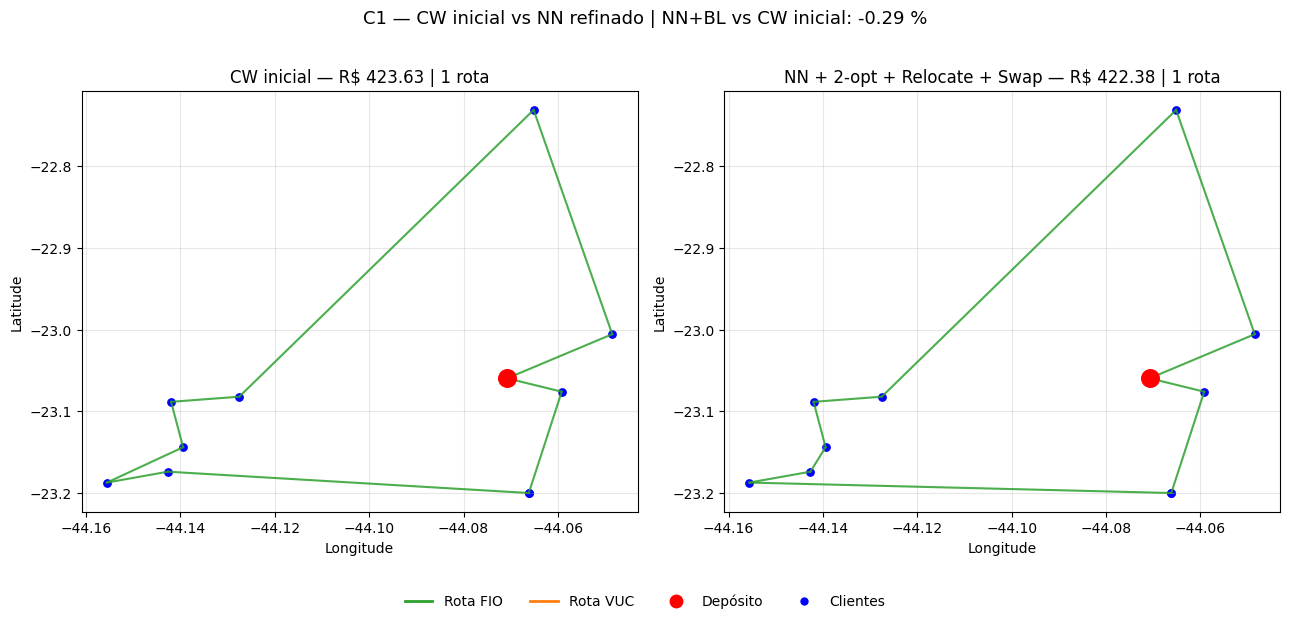

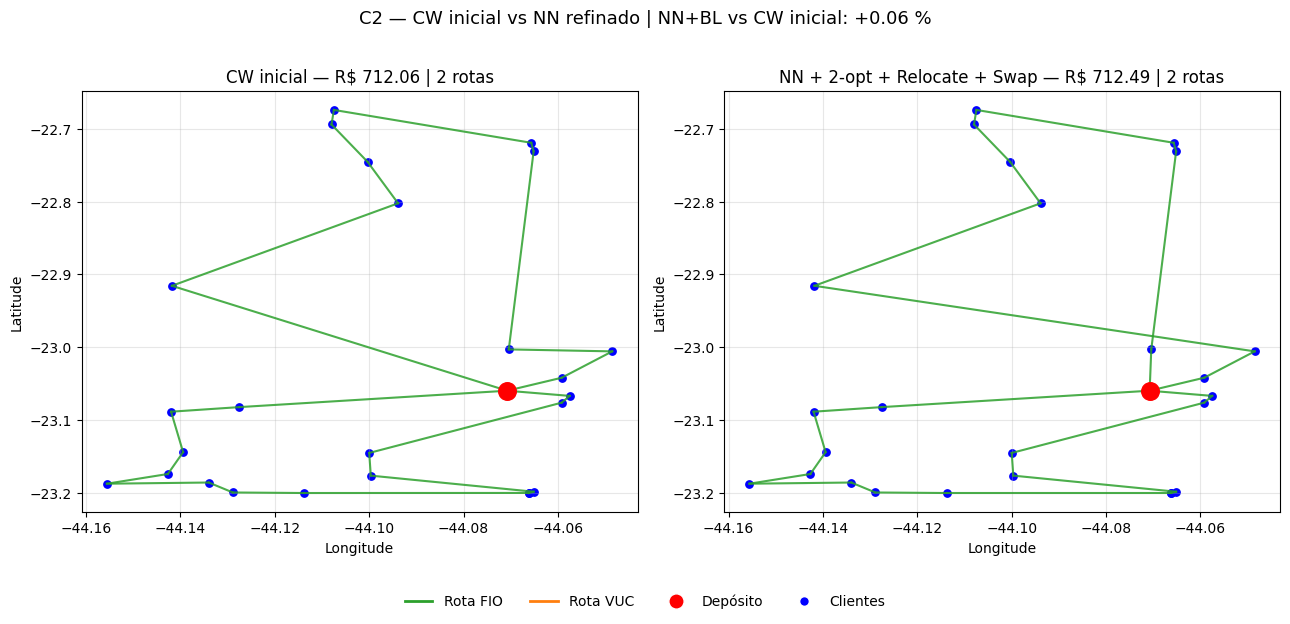

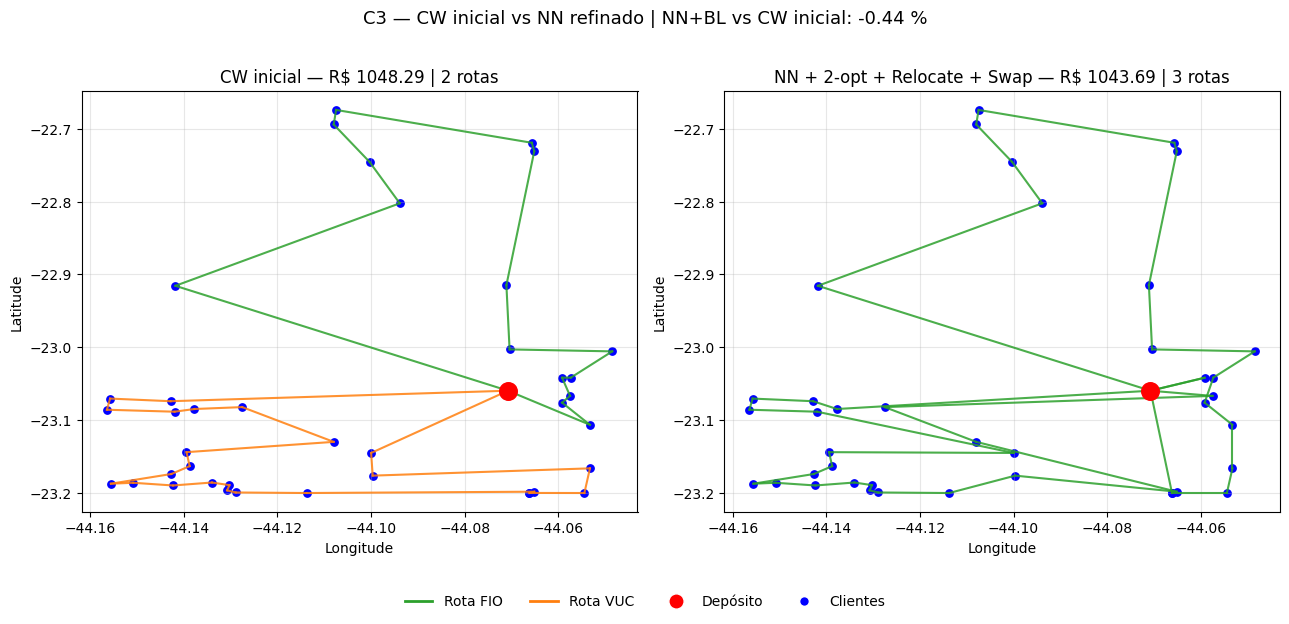

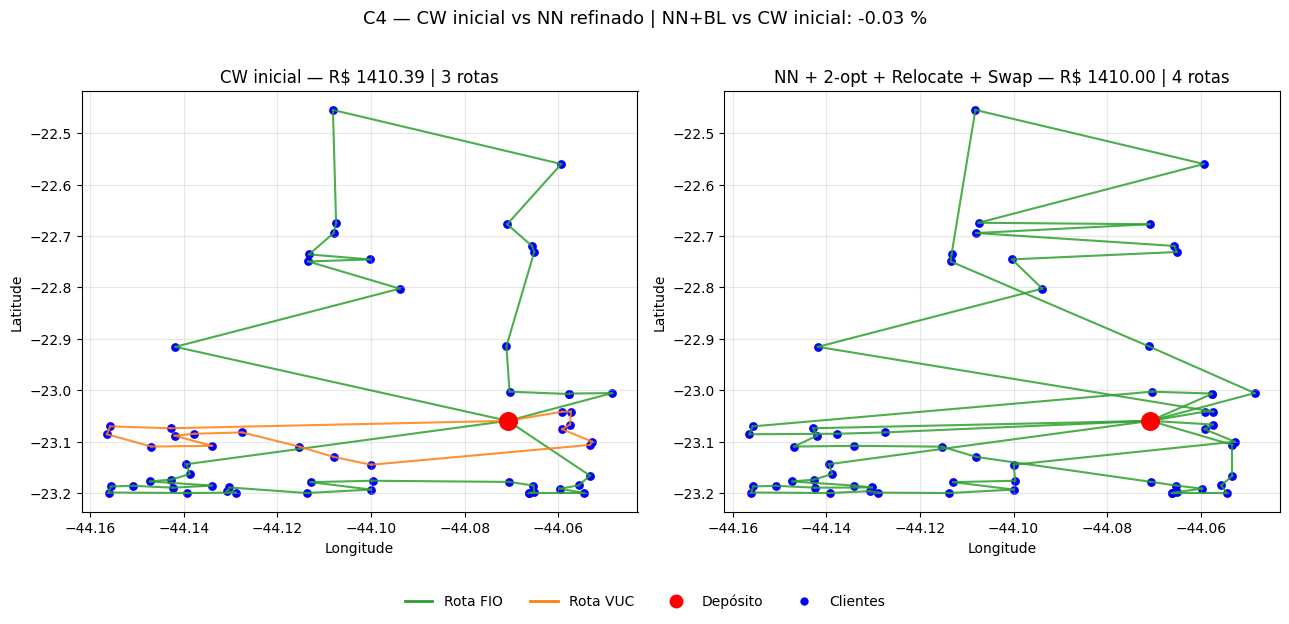

In [18]:
from matplotlib.lines import Line2D


def plot_solution(ax, solution, nodes, title):
    x_coords = nodes["lon"].values
    y_coords = nodes["lat"].values
    ax.scatter(x_coords[1:], y_coords[1:], color="blue", s=28)
    ax.scatter(x_coords[0], y_coords[0], color="red", s=160, zorder=5)
    for item in solution:
        route = item["route"]
        color = "tab:orange" if item["vehicle"] == "VUC" else "tab:green"
        for i in range(len(route) - 1):
            a, b = route[i], route[i + 1]
            ax.plot(
                [x_coords[a], x_coords[b]],
                [y_coords[a], y_coords[b]],
                color=color, linewidth=1.5, alpha=0.85,
            )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)


legend_handles = [
    Line2D([0], [0], color="tab:green", lw=2, label="Rota FIO"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Rota VUC"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=11, label="Depósito"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="blue", markersize=7, label="Clientes"),
]

for name in INSTANCIAS:
    nodes_inst = INST[name]["nodes"]

    sol_cw_ini = solucoes_iniciais["CW"][name]
    custo_cw_ini = solution_metrics(sol_cw_ini, INST[name]["D"], INST[name]["q"],
                                    INST[name]["s"], cost_per_km, f, Q, H, v_kmh)["total_cost_rs"]

    sol_nn_final = solucoes_swap["NN"][name]["solution"]
    custo_nn_final = solucoes_swap["NN"][name]["metrics"]["total_cost_rs"]

    delta_pct = 100 * (custo_nn_final - custo_cw_ini) / custo_cw_ini

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.suptitle(
        f"{name} — CW inicial vs NN refinado | NN+BL vs CW inicial: {delta_pct:+.2f} %",
        fontsize=13, y=1.02,
    )
    plot_solution(
        axes[0], sol_cw_ini, nodes_inst,
        f"CW inicial — R$ {custo_cw_ini:.2f} | {len(sol_cw_ini)} rota{'s' if len(sol_cw_ini) > 1 else ''}",
    )
    plot_solution(
        axes[1], sol_nn_final, nodes_inst,
        f"NN + 2-opt + Relocate + Swap — R$ {custo_nn_final:.2f} | {len(sol_nn_final)} rota{'s' if len(sol_nn_final) > 1 else ''}",
    )
    fig.legend(
        handles=legend_handles, loc="upper center", ncol=4,
        bbox_to_anchor=(0.5, -0.02), frameon=False,
    )
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"rotas_{name}_CW_inicial_vs_NN_busca_local.png", dpi=140, bbox_inches="tight")
    plt.show()

Uma figura por instância isola a comparação CW inicial vs NN refinado sobre o mesmo mapa geográfico — o ponto da seção é ver como o pipeline 2-opt + Relocate + Swap reorganiza geometricamente as rotas do NN e como o resultado final se compara ao CW antes de qualquer busca local. A leitura visual confirma e qualifica os números da seção 10 em cada caso.

Em C1 (`rotas_C1_CW_inicial_vs_NN_busca_local.png`) as duas soluções convergem para a mesma rota única (R$ 422,38); apenas a orientação do tour difere. Em C2 (`rotas_C2_CW_inicial_vs_NN_busca_local.png`) ambas chegam a duas rotas FIO de geometria muito próxima, com diferença residual de R$ 0,44 — vantagem do CW originária de um cruzamento que o pipeline NN+BL não conseguiu remover sob critério de melhoria estrita. Em C3 (`rotas_C3_CW_inicial_vs_NN_busca_local.png`) o contraste estrutural se mantém — CW com partição mista FIO (verde, norte) + VUC (laranja, sul), NN+BL com três rotas FIO entremeadas — mas o Swap finalmente refinou o suficiente para o NN+BL custar R$ 4,30 a menos que o CW: a vantagem do CW na partição inicial é mais que compensada pelos R$ 117 de custo fixo que o NN economiza ao não acionar VUC. C4 (`rotas_C4_CW_inicial_vs_NN_busca_local.png`) repete a estrutura — CW com 2 FIO + 1 VUC vs NN+BL com 4 FIO — agora com NN+BL a R$ 0,21 de vantagem, beirando o empate. Os mapas tornam visível um fenômeno que a tabela apenas numerou: NN com refinamento completo pode vencer CW ao preferir frota homogênea Fiorino com mais rotas a uma partição mista FIO+VUC, quando o custo fixo extra do VUC excede o que ele economiza em distância.

### 11.1 Distância em linha reta × rota operacional real

A pergunta 9 do Sprint Planning 2 — *a melhor rota em distância é a melhor rota operacional?* — exige separar dois conceitos sobrepostos no projeto. As soluções desta aula minimizam distância Haversine entre nós (linha reta sobre a superfície da Terra, derivada das latitudes e longitudes de `nodes.csv`). A operação real da Prolog percorre a malha viária do Rio de Janeiro e Baixada Fluminense, que difere da geometria Haversine por três fatores principais: (i) obstáculos físicos — Baía de Guanabara entre Caxias e Niterói, ilhas, áreas militares — exigem desvios via Ponte Rio-Niterói, Linha Vermelha ou BR-101; (ii) topologia da rede — vias de mão única, retornos restritos, limitações de carga em algumas ruas obrigam o motorista a desviar; (iii) tempo de viagem efetivo varia com congestionamento, horário e dia da semana, enquanto o modelo assume velocidade média constante de 40 km/h.

Para qualquer par de nós `(i, j)` na matriz `D`, a distância Haversine `D[i, j]` é um **limite inferior** sobre a distância viária real `R[i, j]`: `R[i, j] ≥ D[i, j]`. A razão `R/D` cresce quando o par precisa contornar barreiras. A célula abaixo identifica, dentro de C4 (instância de maior espaço de busca), os pares com maior distância Haversine entre clientes em latitudes opostas em relação ao depósito — candidatos naturais a desvio operacional grande porque atravessam a região onde a rota viária é constrangida pela Baía da Guanabara e pelas conexões para Niterói.

In [25]:
nodes_c4 = INST["C4"]["nodes"]
D_c4 = INST["C4"]["D"]
depot_lat = nodes_c4["lat"].iloc[0]

pares = []
for i in range(1, len(nodes_c4)):
    for j in range(i + 1, len(nodes_c4)):
        lat_i = nodes_c4["lat"].iloc[i]
        lat_j = nodes_c4["lat"].iloc[j]
        cep_i = nodes_c4["CEP"].iloc[i]
        cep_j = nodes_c4["CEP"].iloc[j]
        if (lat_i - depot_lat) * (lat_j - depot_lat) >= 0:
            continue
        pares.append({
            "cliente i": int(nodes_c4["id"].iloc[i]),
            "CEP_i": int(cep_i),
            "lat_i": round(lat_i, 4),
            "cliente j": int(nodes_c4["id"].iloc[j]),
            "CEP_j": int(cep_j),
            "lat_j": round(lat_j, 4),
            "D_Haversine (km)": round(D_c4[i, j], 2),
        })

df_pares = pd.DataFrame(pares).sort_values("D_Haversine (km)", ascending=False).head(8).reset_index(drop=True)
df_pares

,cliente i,CEP_i,lat_i,cliente j,CEP_j,lat_j,D_Haversine (km)
0,37,26210000,-23.2000,46,23058281,-22.4547,83.06
1,1,25520000,-23.2000,46,23058281,-22.4547,82.98
2,7,25520001,-23.1999,46,23058281,-22.4547,82.97
3,44,21220000,-23.2000,46,23058281,-22.4547,82.93
4,46,23058281,-22.4547,47,20230011,-23.1990,82.91
5,14,22720000,-23.2000,46,23058281,-22.4547,82.87
6,25,21830008,-23.1993,46,23058281,-22.4547,82.82
7,17,25580020,-23.1982,46,23058281,-22.4547,82.79


A tabela isola pares cujas latitudes ficam em lados opostos do depósito (Caxias, lat ≈ -23,06). O par mais extenso — clientes 37 (CEP 26210-000, Magé/Petrópolis, lat -23,20) e 46 (CEP 23058-281, Bangu/Santa Cruz, lat -22,45) — registra 83,06 km Haversine. A região coberta engloba a Baixada Fluminense (norte de Caxias) e a Zona Oeste do Rio (sul de Caxias). O trajeto rodoviário real entre esses dois pontos passa pela BR-040 ou BR-101 + Avenida Brasil, com distância prática em torno de 95-110 km — entre 15 % e 30 % acima do valor Haversine.

A consequência operacional é direta: rotas que dentro do modelo parecem geometricamente curtas porque cruzam a baía em linha reta podem, no terreno, ser inviáveis ou exigirem o dobro do tempo. Para a Prolog, o uso prático das soluções deste notebook deve passar por duas verificações antes da execução: (i) substituir a matriz Haversine `D` por uma matriz de distâncias reais via serviço de roteamento (OSRM, Google Distance Matrix, HERE) — operação que **conservará a estrutura das rotas** sob a maioria das instâncias mas ajustará tempos e custos variáveis; (ii) reexecutar o pipeline com a nova matriz para garantir que a jornada de 8 h, hoje próxima do limite em 7 das 18 rotas (seção 9.1), continue sendo respeitada quando os deslocamentos reais substituírem o limite inferior Haversine. Em algumas combinações de cliente, o gap Haversine-real pode ser suficiente para tornar uma rota viável no modelo, mas inviável na malha viária — caso em que o engenheiro logístico precisaria reabrir a rota ou trocar o veículo para o VUC.

## 12. Comparação com o método exato (Sprint 1)

Atualizamos a tabela de gap em relação ao MILP da Aula 4 considerando a melhor solução heurística refinada pelo pipeline completo (mínimo entre NN + 2-opt + Relocate + Swap e CW + 2-opt + Relocate + Swap) em cada instância. A leitura segue a mesma observação metodológica da Aula 7: o exato da Sprint 1 incorpora a restrição de saída única por tipo de veículo, ausente nas heurísticas, o que cria assimetria estrutural — não desvantagem genuína do método heurístico.

In [19]:
exato = {
    "C1": {"custo": 422.38, "status": "optimal"},
    "C2": {"custo": 754.04, "status": "optimal"},
    "C3": {"custo": 769.65, "status": "maxTimeLimit"},
    "C4": {"custo": 858.31, "status": "maxTimeLimit"},
}

linhas_exato = []
for name in INSTANCIAS:
    cf_nn = solucoes_swap["NN"][name]["metrics"]["total_cost_rs"]
    cf_cw = solucoes_swap["CW"][name]["metrics"]["total_cost_rs"]
    melhor_heur = min(cf_nn, cf_cw)
    melhor_label = "CW+BL" if cf_cw <= cf_nn else "NN+BL"
    custo_exato = exato[name]["custo"]
    gap = 100 * (melhor_heur - custo_exato) / custo_exato
    linhas_exato.append({
        "instância": name,
        "exato_Aula4 (R$)": round(custo_exato, 2),
        "status_exato": exato[name]["status"],
        "melhor_heur+BL (R$)": round(melhor_heur, 2),
        "origem": melhor_label,
        "gap_vs_exato (%)": round(gap, 2),
    })

df_exato = pd.DataFrame(linhas_exato)
df_exato

,instância,exato_Aula4 (R$),status_exato,melhor_heur+BL (R$),origem,gap_vs_exato (%)
0,C1,422.38,optimal,422.38,CW+BL,0.00
1,C2,754.04,optimal,712.05,CW+BL,-5.57
2,C3,769.65,maxTimeLimit,1043.69,NN+BL,35.61
3,C4,858.31,maxTimeLimit,1410.00,NN+BL,64.28


Em C1 a heurística refinada **iguala o ótimo global** (R$ 422,38) — o pipeline completo de busca local sobre NN e CW convergiu para a solução ótima do MILP. Em C2 a heurística refinada **supera o exato em 5,57 %** (R$ 712,05 contra R$ 754,04), confirmação do mesmo fenômeno já observado na Aula 7: a restrição de saída única por tipo na formulação MILP da Aula 4 proíbe configurações com mais de uma rota Fiorino, que são justamente as escolhidas pela heurística. Em C3 e C4 o gap aparente segue grande (35,61 % e 64,28 %), mas reflete uma diferença de regime: o exato consolida toda a demanda em um único VUC (não permitido pela formulação atual), enquanto a heurística mantém três e quatro rotas Fiorino, respectivamente. O Swap reduziu o gap em C3 de 36,16 % para 35,61 % e em C4 de 64,30 % para 64,28 % — refinamento marginal, porque a barreira é estrutural (regime de frota) e não posicional.

A leitura operacional é direta: para a Prolog, **NN + 2-opt + Relocate + Swap** passa a ser a melhor heurística em C3 e C4, com vantagem de R$ 4,30 e R$ 0,21 sobre o CW+BL; em C1 e C2 o CW+BL continua sendo o melhor candidato (e supera o exato em C2). O protocolo recomendado fica: rodar os dois pontos de partida com o pipeline completo, ficar com o menor — custo computacional total < 3,5 s na maior instância. A refatoração do MILP para permitir múltiplas rotas por tipo segue sendo prerrequisito para uma comparação justa nas instâncias maiores.

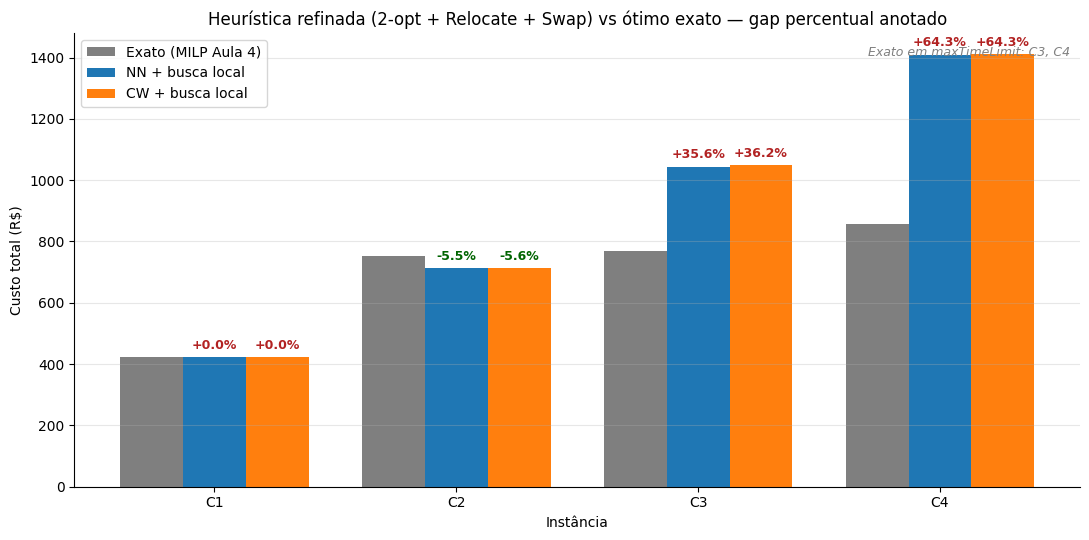

In [20]:
import numpy as np

instancias_plot = INSTANCIAS
x = np.arange(len(instancias_plot))
width = 0.26

custos_exato = [exato[name]["custo"] for name in instancias_plot]
custos_nn_bl = [solucoes_swap["NN"][name]["metrics"]["total_cost_rs"] for name in instancias_plot]
custos_cw_bl = [solucoes_swap["CW"][name]["metrics"]["total_cost_rs"] for name in instancias_plot]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width, custos_exato, width, label="Exato (MILP Aula 4)", color="#7f7f7f")
bars_nn = ax.bar(x, custos_nn_bl, width, label="NN + busca local", color="#1f77b4")
bars_cw = ax.bar(x + width, custos_cw_bl, width, label="CW + busca local", color="#ff7f0e")

for bars, custos in [(bars_nn, custos_nn_bl), (bars_cw, custos_cw_bl)]:
    for bar, custo, exato_c in zip(bars, custos, custos_exato):
        gap = 100 * (custo - exato_c) / exato_c
        cor = "darkgreen" if gap < 0 else "firebrick"
        ax.annotate(
            f"{gap:+.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4), textcoords="offset points",
            ha="center", va="bottom", fontsize=9, color=cor, fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels(instancias_plot)
ax.set_xlabel("Instância")
ax.set_ylabel("Custo total (R$)")
ax.set_title("Heurística refinada (2-opt + Relocate + Swap) vs ótimo exato — gap percentual anotado")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

status_marks = [name for name in instancias_plot if exato[name]["status"] != "optimal"]
if status_marks:
    ax.text(
        0.99, 0.97,
        f"Exato em maxTimeLimit: {', '.join(status_marks)}",
        transform=ax.transAxes, fontsize=9, ha="right", va="top",
        style="italic", color="gray",
    )

plt.tight_layout()
plt.savefig(IMAGES_DIR / "custos_exato_vs_heuristicas_BL.png", dpi=140, bbox_inches="tight")
plt.show()

O gráfico `custos_exato_vs_heuristicas_BL.png` torna direta a comparação entre as três rotas de solução nas quatro instâncias após o pipeline completo. Em C1 as três barras ficam praticamente coladas em R$ 422,38 — a heurística refinada iguala o ótimo global e ambos os rótulos aparecem em verde com 0,0 %. Em C2 as barras do CW+BL (R$ 712,05) e do NN+BL (R$ 712,49) ficam visivelmente abaixo da do exato (R$ 754,04), com rótulos verdes de -5,57 % e -5,51 %: ambas as heurísticas refinadas batem o exato, fenômeno explicado pela restrição de saída única por tipo na formulação MILP da Aula 4 que proíbe a configuração de duas rotas Fiorino. Em C3 e C4 o exato volta a ficar abaixo das heurísticas, com gaps de +35,6 % e +64,3 % anotados em vermelho, refletindo o regime "tudo em um único VUC" permitido pela formulação atual e fora do espaço de busca das heurísticas com a granularidade atual de frota. Em C3 o NN+BL passou a ser inclusive marginalmente melhor que o CW+BL (gap +35,6 % vs +36,2 %), inversão produzida exclusivamente pelo Swap.

A comparação direta com o gráfico análogo da Aula 7 (`custos_exato_vs_heuristicas.png`) revela onde a busca local completa foi efetiva: o gap caiu de +0,30 % (CW) e +1,95 % (NN) em C1 para 0 % nos dois, e em C3-C4 o pipeline reduziu o gap em ~0,6 e ~0,02 pontos percentuais — refinamento marginal porque a barreira em C3-C4 é estrutural (regime de frota), não posicional. A leitura empírica confirma o que a seção 10 já apontava em prosa: a busca local sob melhoria estrita captura ganhos onde a vizinhança é suficiente (rotas pequenas ou desbalanceadas que admitem reorganização inter-rota) e fica neutra onde o ótimo local depende de uma transição que momentaneamente piora o custo — barreira que metaheurísticas da Sprint 3 são projetadas para vencer.

## 13. Persistência das soluções para a Sprint 3

Salvamos os 8 JSONs finais em `files/`, agora carregando a solução pós-Swap como ponto de partida das metaheurísticas da Sprint 3. O wrapper segue o mesmo formato da Aula 7 (`heuristic`, `instance`, `criterion`, `solution`, `metrics`, `elapsed_s`), com o campo `pipeline` atualizado para refletir as três etapas (`["initial", "2-opt", "relocate", "swap"]`) e `elapsed_s` decomposto por movimento. A pasta `files/` da Aula 8 contém o resultado consolidado da Sprint 2.

In [21]:
def _python_safe(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: _python_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_python_safe(v) for v in obj]
    return obj


arquivos_salvos = []
for heur in HEURISTICAS:
    for name in INSTANCIAS:
        payload = {
            "heuristic_initial": heur,
            "instance": name,
            "criterion": CRITERIO,
            "pipeline": ["initial", "2-opt", "relocate", "swap"],
            "solution": _python_safe(solucoes_swap[heur][name]["solution"]),
            "metrics": _python_safe(solucoes_swap[heur][name]["metrics"]),
            "elapsed_s": {
                "2opt": solucoes_2opt[heur][name]["elapsed_s"],
                "relocate": solucoes_final[heur][name]["elapsed_s"],
                "swap": solucoes_swap[heur][name]["elapsed_s"],
            },
        }
        fname = f"solution_busca_local_{heur.lower()}_{name}.json"
        (OUTPUT_FILES_DIR / fname).write_text(
            json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8",
        )
        arquivos_salvos.append(fname)

print(f"{len(arquivos_salvos)} arquivos salvos em {OUTPUT_FILES_DIR.resolve()}:")
for fname in arquivos_salvos:
    print("  -", fname)

8 arquivos salvos em C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\8\Aula8_Busca_Local\files:
  - solution_busca_local_nn_C1.json
  - solution_busca_local_nn_C2.json
  - solution_busca_local_nn_C3.json
  - solution_busca_local_nn_C4.json
  - solution_busca_local_cw_C1.json
  - solution_busca_local_cw_C2.json
  - solution_busca_local_cw_C3.json
  - solution_busca_local_cw_C4.json
